In [3]:
import pandas as pd
import numpy as np
import pyodbc
import warnings

pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 50)

def run_sql(query):
    with pyodbc.connect("DSN=Redshift_prod_new") as conn:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=conn)
        warnings.filterwarnings("default", category=UserWarning)
    return df

with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    conn.cursor().execute("SELECT 1").fetchone()
print("ODBC connection OK")

ODBC connection OK


In [4]:
ragu_df = run_sql("""
    SELECT account_number, lob, book_date,
           gross_loss_ragu, ltv, amt_financed, model_score
    FROM sandbox.gl_ragu_individual
    WHERE gross_loss_ragu IS NOT NULL
""")

ragu_df['book_date'] = pd.to_datetime(ragu_df['book_date'])
print(f"Rows: {len(ragu_df):,}")
print(f"\nLOB distribution:")
print(ragu_df['lob'].value_counts())

print("\n--- gross_loss_ragu range by LOB ---")
print(ragu_df.groupby('lob')['gross_loss_ragu'].describe(
    percentiles=[0.25, 0.5, 0.75]
)[['min', '25%', '50%', '75%', 'max']].round(2))

print("\n--- LTV range by LOB ---")
print(ragu_df.groupby('lob')['ltv'].describe(
    percentiles=[0.25, 0.5, 0.75]
)[['min', '25%', '50%', '75%', 'max']].round(3))

Rows: 818,180

LOB distribution:
lob
KMX    429414
FRN    116750
ENT    101365
STG     88248
AN      49442
FLD     32961
Name: count, dtype: int64

--- gross_loss_ragu range by LOB ---
        min     25%     50%     75%     max
lob                                        
AN    97.70  131.93  138.69  145.00  192.50
ENT  102.04  128.69  133.88  139.12  192.12
FLD   99.96  133.67  140.04  145.75  204.50
FRN   92.00  134.10  140.71  146.50  209.50
KMX   78.00  133.08  139.81  146.72  235.26
STG   91.58  131.69  138.83  145.29  206.50

--- LTV range by LOB ---
       min    25%    50%    75%     max
lob                                    
AN   0.128  1.311  1.607  2.080  46.927
ENT  0.155  1.202  1.316  1.436  11.924
FLD  0.056  1.170  1.334  1.580  11.184
FRN  0.146  1.266  1.508  1.890  30.804
KMX  0.013  1.274  1.508  1.973  30.832
STG  0.095  1.263  1.526  1.992  27.478


In [5]:
print("=" * 70)
print("LTV DISTRIBUTION BY LOB")
print("=" * 70)
print(ragu_df.groupby('lob')['ltv'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)[['min', '10%', '25%', '50%', '75%', '90%', 'max']].round(3))

print(f"\n{'=' * 70}")
print("GROSS LOSS RAGU DISTRIBUTION BY LOB")
print("=" * 70)
print(ragu_df.groupby('lob')['gross_loss_ragu'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)[['count', 'min', '10%', '25%', '50%', '75%', '90%', 'max']].round(2))

LTV DISTRIBUTION BY LOB


       min    10%    25%    50%    75%    90%     max
lob                                                  
AN   0.128  1.106  1.311  1.607  2.080  2.700  46.927
ENT  0.155  1.095  1.202  1.316  1.436  1.565  11.924
FLD  0.056  1.010  1.170  1.334  1.580  1.953  11.184
FRN  0.146  1.064  1.266  1.508  1.890  2.480  30.804
KMX  0.013  1.126  1.274  1.508  1.973  2.669  30.832
STG  0.095  1.056  1.263  1.526  1.992  2.688  27.478

GROSS LOSS RAGU DISTRIBUTION BY LOB
        count     min     10%     25%     50%     75%     90%     max
lob                                                                  
AN    49442.0   97.70  126.00  131.93  138.69  145.00  151.50  192.50
ENT  101365.0  102.04  124.09  128.69  133.88  139.12  143.93  192.12
FLD   32961.0   99.96  126.96  133.67  140.04  145.75  151.52  204.50
FRN  116750.0   92.00  127.44  134.10  140.71  146.50  152.37  209.50
KMX  429414.0   78.00  127.00  133.08  139.81  146.72  153.61  235.26
STG   88248.0   91.58  124.60  131.69  13

In [6]:
actuals_df = run_sql("""
    WITH all_accounts AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(proceeds) AS proceeds
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
        GROUP BY 1, 2
    ),
    chargeoffs AS (
        SELECT account_number,
               sp_book_date_quarter_vintage,
               MAX(gross_loss_amt) AS gross_loss_amt,
               MAX(net_loss_amt) AS net_loss_amt
        FROM edwnpi.svc_master_monthend
        WHERE sp_book_date_quarter_vintage >= '2020 Q1'
          AND account_life_cycle = 'CHARGEOFF'
        GROUP BY 1, 2
    )
    SELECT a.account_number,
           a.sp_book_date_quarter_vintage AS vintage,
           a.proceeds,
           COALESCE(co.gross_loss_amt, 0) AS gross_loss_amt,
           COALESCE(co.net_loss_amt, 0) AS net_loss_amt,
           CASE WHEN co.account_number IS NOT NULL THEN 1 ELSE 0 END AS is_chargeoff
    FROM all_accounts a
    LEFT JOIN chargeoffs co
        ON a.account_number = co.account_number
       AND a.sp_book_date_quarter_vintage = co.sp_book_date_quarter_vintage
""")

print(f"Actuals rows: {len(actuals_df):,}")
print(f"Chargeoff rate: {actuals_df['is_chargeoff'].mean():.4f}")
print(f"Vintages: {actuals_df['vintage'].nunique()}")
print(f"Vintage range: {actuals_df['vintage'].min()} to {actuals_df['vintage'].max()}")

Actuals rows: 929,442
Chargeoff rate: 0.3432
Vintages: 27
Vintage range: 2020 Q1 to 225 Q4


In [19]:
merged = ragu_df.merge(
    actuals_df[['account_number', 'vintage', 'proceeds', 'gross_loss_amt', 'net_loss_amt']],
    on='account_number', how='inner'
)

print(f"Pre-filter merged rows: {len(merged):,}")
print(f"Book date range in gl_ragu_individual: {merged['book_date'].min()} to {merged['book_date'].max()}")

MATURITY_CUTOFF = '2023-12-31'
merged = merged[merged['book_date'] <= MATURITY_CUTOFF].copy()

merged['gross_loss_pct'] = merged['gross_loss_amt'] / merged['proceeds']
merged['cnl_pct'] = merged['net_loss_amt'] / merged['proceeds']
merged['recovery_pct'] = merged['gross_loss_pct'] - merged['cnl_pct']

# LTV bands: 5% wide from 100% to 200%
LTV_MIN, LTV_MAX, LTV_STEP = 1.00, 2.00, 0.05
ltv_bins = np.arange(LTV_MIN, LTV_MAX + LTV_STEP, LTV_STEP)
ltv_labels = [f"{b:.0%}-{b + LTV_STEP:.0%}" for b in ltv_bins[:-1]]
merged['ltv_band'] = pd.cut(merged['ltv'], bins=ltv_bins, labels=ltv_labels, right=False)

# Gross loss RAGU quintiles (combined non-KMX population)
merged['gl_ragu_quintile'] = pd.qcut(
    merged['gross_loss_ragu'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

print(f"\nAfter maturity filter (<= {MATURITY_CUTOFF}): {len(merged):,} rows")
print(f"Book date range: {merged['book_date'].min()} to {merged['book_date'].max()}")
print(f"\nLTV band coverage: {merged['ltv_band'].notna().sum():,} / {len(merged):,} "
      f"({merged['ltv_band'].notna().mean():.1%} within [{LTV_MIN:.0%}, {LTV_MAX:.0%}])")
print(f"\nLOB counts:")
print(merged['lob'].value_counts().sort_index())

Pre-filter merged rows: 805,967
Book date range in gl_ragu_individual: 2020-01-02 00:00:00 to 2026-06-30 00:00:00

After maturity filter (<= 2023-12-31): 449,826 rows
Book date range: 2020-01-02 00:00:00 to 2023-12-30 00:00:00

LTV band coverage: 278,089 / 449,826 (61.8% within [100%, 200%])

LOB counts:
lob
AN      25624
ENT     55226
FLD     14348
FRN     46083
KMX    261592
STG     46953
Name: count, dtype: int64


In [20]:
print("=" * 70)
print("COMBINED NON-KMX DISTRIBUTION SUMMARY (merged dataset)")
print("=" * 70)

summary = pd.DataFrame({
    'count': [len(merged)],
    'gl_ragu_min': [merged['gross_loss_ragu'].min()],
    'gl_ragu_p25': [merged['gross_loss_ragu'].quantile(0.25)],
    'gl_ragu_median': [merged['gross_loss_ragu'].median()],
    'gl_ragu_p75': [merged['gross_loss_ragu'].quantile(0.75)],
    'gl_ragu_max': [merged['gross_loss_ragu'].max()],
    'mean_ltv': [merged['ltv'].mean()],
    'gross_loss_rate': [merged['gross_loss_pct'].mean()],
    'cnl_rate': [merged['cnl_pct'].mean()],
    'recovery_rate': [merged['recovery_pct'].mean()],
}).round(4)

display(summary)

print(f"\n--- Gross Loss RAGU quintile ranges ---")
print(merged.groupby('gl_ragu_quintile', observed=True)['gross_loss_ragu'].agg(['min', 'max', 'count']).round(2))

COMBINED NON-KMX DISTRIBUTION SUMMARY (merged dataset)


,count,gl_ragu_min,gl_ragu_p25,gl_ragu_median,gl_ragu_p75,gl_ragu_max,mean_ltv,gross_loss_rate,cnl_rate,recovery_rate
0,449826,78.0,129.8015,136.6872,144.432,235.2619,1.7056,0.4174,0.3373,0.0802



--- Gross Loss RAGU quintile ranges ---
                     min     max  count
gl_ragu_quintile                       
Q1 (Low)           78.00  128.16  89966
Q2                128.16  134.02  89974
Q3                134.02  139.50  89957
Q4                139.50  146.47  89965
Q5 (High)         146.47  235.26  89964


In [21]:
analysis_df = merged[merged['ltv_band'].notna()].copy()

# Quintile range labels for column headers
q_ranges = analysis_df.groupby('gl_ragu_quintile', observed=True)['gross_loss_ragu'].agg(['min', 'max', 'count'])
q_ranges.columns = ['gl_min', 'gl_max', 'n']
q_ranges['col_label'] = q_ranges.apply(lambda r: f"[{r.gl_min:.1f}, {r.gl_max:.1f}]", axis=1)

grouped = analysis_df.groupby(['ltv_band', 'gl_ragu_quintile'], observed=True).agg(
    total_gross_loss=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()

grouped['recovery_rate'] = (grouped['total_gross_loss'] - grouped['total_cnl']) / grouped['total_proceeds']

# --- Performance table (recovery = gross loss - CNL, as % of proceeds) ---
pivot_rate = grouped.pivot(index='ltv_band', columns='gl_ragu_quintile', values='recovery_rate')
display_rate = pivot_rate.copy() * 100
col_rename = {q: f"{q}\n{q_ranges.loc[q, 'col_label']}" for q in q_ranges.index}
display_rate = display_rate.rename(columns=col_rename)

print("=" * 80)
print("RECOVERY RATE (%) = (Gross Loss - CNL) / Proceeds  --  NON-KMX COMBINED")
print("Rows: LTV 5% bands | Columns: Gross Loss RAGU quintiles")
print("=" * 80)
display(display_rate.round(3))

# --- Loan count mirror table ---
pivot_count = grouped.pivot(index='ltv_band', columns='gl_ragu_quintile', values='loan_count')
display_count = pivot_count.copy()
display_count = display_count.rename(columns=col_rename)

print(f"\n{'=' * 80}")
print("LOAN COUNT  --  NON-KMX COMBINED")
print("Rows: LTV 5% bands | Columns: Gross Loss RAGU quintiles")
print("=" * 80)
display(display_count)

RECOVERY RATE (%) = (Gross Loss - CNL) / Proceeds  --  NON-KMX COMBINED
Rows: LTV 5% bands | Columns: Gross Loss RAGU quintiles


gl_ragu_quintile,"Q1 (Low)\n[89.9, 128.2]","Q2\n[128.2, 134.0]","Q3\n[134.0, 139.5]","Q4\n[139.5, 146.5]","Q5 (High)\n[146.5, 222.5]"
ltv_band,,,,,
100%-105%,13.479,10.370,8.719,8.084,5.776
105%-110%,12.145,10.855,9.526,8.229,5.927
110%-115%,11.942,10.390,10.309,8.522,6.736
115%-120%,13.185,10.718,9.677,8.397,6.055
120%-125%,12.838,11.160,9.859,9.092,6.500
125%-130%,12.264,11.037,9.934,8.592,6.432
130%-135%,12.647,11.268,9.927,8.770,6.214
135%-140%,11.949,11.057,8.686,8.276,5.655
140%-145%,12.325,11.276,9.465,8.185,5.699



LOAN COUNT  --  NON-KMX COMBINED
Rows: LTV 5% bands | Columns: Gross Loss RAGU quintiles


gl_ragu_quintile,"Q1 (Low)\n[89.9, 128.2]","Q2\n[128.2, 134.0]","Q3\n[134.0, 139.5]","Q4\n[139.5, 146.5]","Q5 (High)\n[146.5, 222.5]"
ltv_band,,,,,
100%-105%,1322,1561,1830,1935,2526
105%-110%,1867,2207,2411,2644,3108
110%-115%,2487,3047,3072,3320,3457
115%-120%,3144,3866,3881,3706,3714
120%-125%,3843,4458,4244,4142,3872
125%-130%,4346,4871,4511,4175,3775
130%-135%,4307,4965,4607,4143,3587
135%-140%,4255,4694,4378,3903,3530
140%-145%,4062,4423,4050,3703,3113


In [22]:
from scipy.stats import linregress

print("=" * 80)
print("REGRESSION: Recovery Rate vs LTV within each Gross Loss RAGU Quintile")
print("=" * 80)
print(f"\n{'Quintile':<12} {'Slope (d Recovery/d LTV)':<28} {'Intercept':<12} {'R-sq':<8} {'N bands':<8}")
print("-" * 68)

for quintile in pivot_rate.columns:
    col = pivot_rate[quintile]
    valid = col.dropna()
    if len(valid) < 3:
        print(f"{quintile:<12} {'insufficient data':<50}")
        continue

    ltv_midpoints = np.array([
        LTV_MIN + i * LTV_STEP + LTV_STEP / 2
        for i, lbl in enumerate(ltv_labels) if lbl in valid.index
    ])
    y = valid.values

    slope, intercept, r_value, p_value, std_err = linregress(ltv_midpoints, y)

    print(f"{quintile:<12} {slope:>+.6f}{'':>14} {intercept:>+.6f}    {r_value**2:.3f}    {len(valid)}")

print(f"\nInterpretation: A positive slope means higher LTV is associated with")
print(f"higher recovery (gross loss - CNL) as a fraction of proceeds.")

REGRESSION: Recovery Rate vs LTV within each Gross Loss RAGU Quintile

Quintile     Slope (d Recovery/d LTV)     Intercept    R-sq     N bands 
--------------------------------------------------------------------
Q1 (Low)     -0.031840               +0.164950    0.762    20
Q2           -0.021567               +0.135189    0.522    20
Q3           -0.018367               +0.117987    0.531    20
Q4           -0.021140               +0.110552    0.686    20
Q5 (High)    -0.017451               +0.083258    0.529    20

Interpretation: A positive slope means higher LTV is associated with
higher recovery (gross loss - CNL) as a fraction of proceeds.


In [11]:
EXCEL_OUTPUT = '../output/ltv_heuristic_validation.xlsx'

with pd.ExcelWriter(EXCEL_OUTPUT, engine='openpyxl') as writer:
    display_rate.round(4).to_excel(writer, sheet_name='Recovery Rate')
    display_count.to_excel(writer, sheet_name='Loan Count')

print(f"Exported to {EXCEL_OUTPUT}")
print(f"  - 'Recovery Rate' sheet: {display_rate.shape[0]} rows x {display_rate.shape[1]} columns")
print(f"  - 'Loan Count' sheet:    {display_count.shape[0]} rows x {display_count.shape[1]} columns")

PermissionError: [Errno 13] Permission denied: '../output/ltv_heuristic_validation.xlsx'

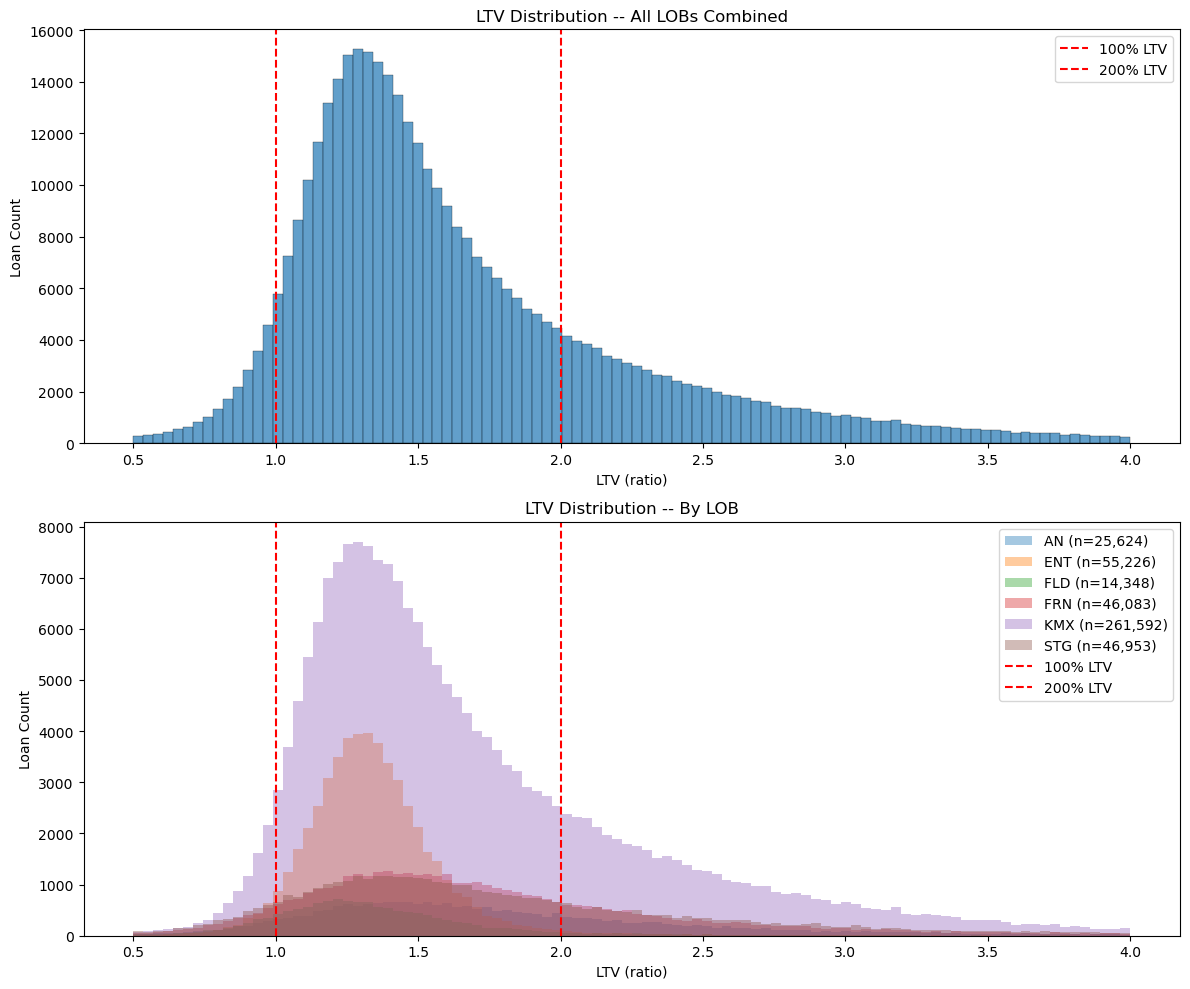


Population coverage by LTV range:
  Below 100%:    23,376 (5.2%)
  100% - 200%:  278,080 (61.8%)
  Above 200%:    88,534 (19.7%)


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Combined distribution
axes[0].hist(merged['ltv'], bins=100, range=(0.5, 4.0), edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].axvline(x=1.00, color='red', linestyle='--', label='100% LTV')
axes[0].axvline(x=2.00, color='red', linestyle='--', label='200% LTV')
axes[0].set_xlabel('LTV (ratio)')
axes[0].set_ylabel('Loan Count')
axes[0].set_title('LTV Distribution -- All LOBs Combined')
axes[0].legend()

# By LOB
LOBS = sorted(merged['lob'].unique())
for lob in LOBS:
    lob_data = merged[merged['lob'] == lob]['ltv']
    axes[1].hist(lob_data, bins=100, range=(0.5, 4.0), alpha=0.4, label=f"{lob} (n={len(lob_data):,})")

axes[1].axvline(x=1.00, color='red', linestyle='--', label='100% LTV')
axes[1].axvline(x=2.00, color='red', linestyle='--', label='200% LTV')
axes[1].set_xlabel('LTV (ratio)')
axes[1].set_ylabel('Loan Count')
axes[1].set_title('LTV Distribution -- By LOB')
axes[1].legend()

plt.tight_layout()
plt.savefig('ltv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPopulation coverage by LTV range:")
print(f"  Below 100%:  {(merged['ltv'] < 1.00).sum():>8,} ({(merged['ltv'] < 1.00).mean():.1%})")
print(f"  100% - 200%: {((merged['ltv'] >= 1.00) & (merged['ltv'] < 2.00)).sum():>8,} ({((merged['ltv'] >= 1.00) & (merged['ltv'] < 2.00)).mean():.1%})")
print(f"  Above 200%:  {(merged['ltv'] >= 2.00).sum():>8,} ({(merged['ltv'] >= 2.00).mean():.1%})")

Middle 80% of gross_loss_ragu: [123.90, 152.25]
Loans in middle 80%: 359,860 / 449,826 (80.0%)


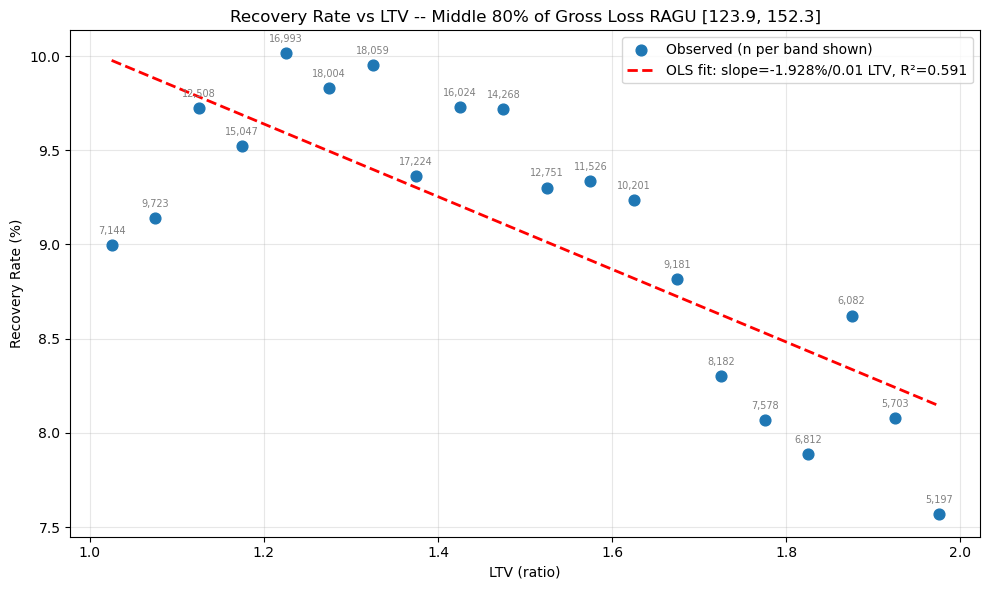


OLS Regression (middle 80% of gross_loss_ragu, pooled):
  Slope:     -0.019281 (recovery rate per unit LTV)
  Intercept: +0.119531
  R-squared: 0.5910
  N bands:   20

  Per 5% LTV increase: -0.096 percentage points of recovery


In [24]:
# Middle 80% of gross_loss_ragu (trim top and bottom 10%)
p10 = merged['gross_loss_ragu'].quantile(0.10)
p90 = merged['gross_loss_ragu'].quantile(0.90)
mid80 = merged[(merged['gross_loss_ragu'] >= p10) & (merged['gross_loss_ragu'] <= p90)].copy()

print(f"Middle 80% of gross_loss_ragu: [{p10:.2f}, {p90:.2f}]")
print(f"Loans in middle 80%: {len(mid80):,} / {len(merged):,} ({len(mid80)/len(merged):.1%})")

# Aggregate recovery rate by LTV band for the middle 80%
mid80_analysis = mid80[mid80['ltv_band'].notna()].copy()
mid80_grouped = mid80_analysis.groupby('ltv_band', observed=True).agg(
    total_gross_loss=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()
mid80_grouped['recovery_rate'] = (mid80_grouped['total_gross_loss'] - mid80_grouped['total_cnl']) / mid80_grouped['total_proceeds']

# LTV midpoints for regression
ltv_midpoints = np.array([LTV_MIN + i * LTV_STEP + LTV_STEP / 2 for i in range(len(ltv_labels))])
valid_mask = mid80_grouped['loan_count'] >= 100
x = ltv_midpoints[valid_mask.values]
y = mid80_grouped.loc[valid_mask, 'recovery_rate'].values

slope, intercept, r_value, p_value, std_err = linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ltv_midpoints, mid80_grouped['recovery_rate'] * 100, s=60, zorder=3,
           label=f'Observed (n per band shown)')
ax.plot(x, (intercept + slope * x) * 100, 'r--', linewidth=2,
        label=f'OLS fit: slope={slope*100:.3f}%/0.01 LTV, R²={r_value**2:.3f}')

for i, row in mid80_grouped.iterrows():
    ax.annotate(f"{row['loan_count']:,.0f}", (ltv_midpoints[i], row['recovery_rate'] * 100),
                textcoords="offset points", xytext=(0, 8), ha='center', fontsize=7, color='gray')

ax.set_xlabel('LTV (ratio)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Recovery Rate vs LTV -- Middle 80% of Gross Loss RAGU [{p10:.1f}, {p90:.1f}]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('recovery_vs_ltv_mid80.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOLS Regression (middle 80% of gross_loss_ragu, pooled):")
print(f"  Slope:     {slope:+.6f} (recovery rate per unit LTV)")
print(f"  Intercept: {intercept:+.6f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  N bands:   {valid_mask.sum()}")
print(f"\n  Per 5% LTV increase: {slope * 0.05 * 100:+.3f} percentage points of recovery")

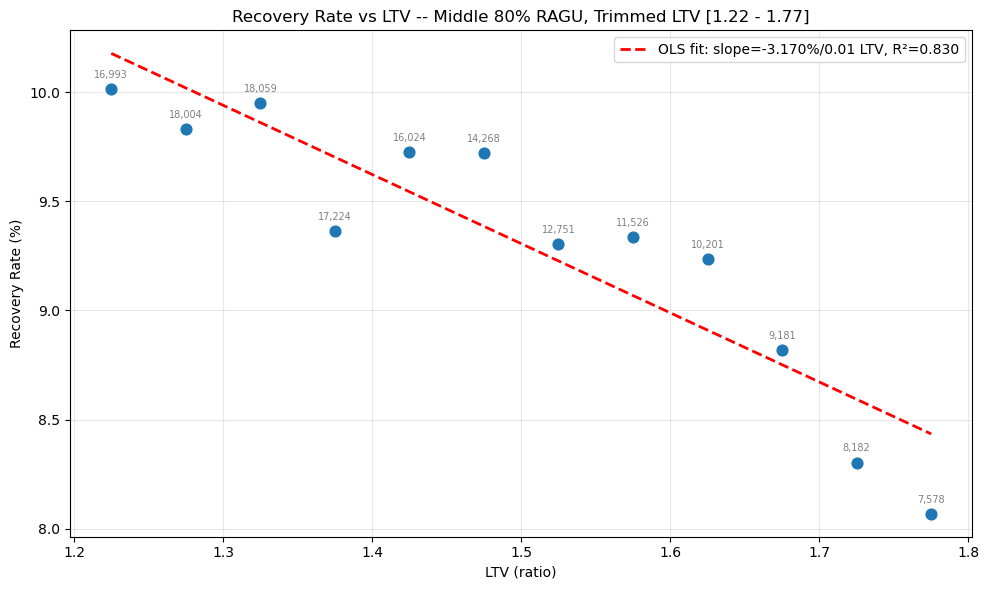


OLS Regression (middle 80% RAGU, excluding top/bottom 2 LTV bands):
  LTV range:  [1.22, 1.77]
  Slope:      -0.031705 (recovery rate per unit LTV)
  Intercept:  +0.140617
  R-squared:  0.8304
  N bands:    12

  Per 5% LTV increase: -0.159 percentage points of recovery

  Comparison to full range:
    Full:    slope=-0.019281, R²=0.5910
    Trimmed: slope=-0.031705, R²=0.8304


In [25]:
# Exclude top 2 and bottom 2 LTV bands from the middle-80% regression
mid80_trimmed = mid80_grouped.iloc[4:-4].copy()
ltv_midpoints_trimmed = ltv_midpoints[4:-4]

valid_mask_t = mid80_trimmed['loan_count'] >= 100
x_t = ltv_midpoints_trimmed[valid_mask_t.values]
y_t = mid80_trimmed.loc[valid_mask_t, 'recovery_rate'].values

slope_t, intercept_t, r_value_t, p_value_t, std_err_t = linregress(x_t, y_t)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ltv_midpoints_trimmed, mid80_trimmed['recovery_rate'].values * 100, s=60, zorder=3)
ax.plot(x_t, (intercept_t + slope_t * x_t) * 100, 'r--', linewidth=2,
        label=f'OLS fit: slope={slope_t*100:.3f}%/0.01 LTV, R²={r_value_t**2:.3f}')

for i, (_, row) in enumerate(mid80_trimmed.iterrows()):
    ax.annotate(f"{row['loan_count']:,.0f}", (ltv_midpoints_trimmed[i], row['recovery_rate'] * 100),
                textcoords="offset points", xytext=(0, 8), ha='center', fontsize=7, color='gray')

ax.set_xlabel('LTV (ratio)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Recovery Rate vs LTV -- Middle 80% RAGU, Trimmed LTV [{ltv_midpoints_trimmed[0]:.2f} - {ltv_midpoints_trimmed[-1]:.2f}]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('recovery_vs_ltv_mid80_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOLS Regression (middle 80% RAGU, excluding top/bottom 2 LTV bands):")
print(f"  LTV range:  [{ltv_midpoints_trimmed[0]:.2f}, {ltv_midpoints_trimmed[-1]:.2f}]")
print(f"  Slope:      {slope_t:+.6f} (recovery rate per unit LTV)")
print(f"  Intercept:  {intercept_t:+.6f}")
print(f"  R-squared:  {r_value_t**2:.4f}")
print(f"  N bands:    {valid_mask_t.sum()}")
print(f"\n  Per 5% LTV increase: {slope_t * 0.05 * 100:+.3f} percentage points of recovery")
print(f"\n  Comparison to full range:")
print(f"    Full:    slope={slope:+.6f}, R²={r_value**2:.4f}")
print(f"    Trimmed: slope={slope_t:+.6f}, R²={r_value_t**2:.4f}")

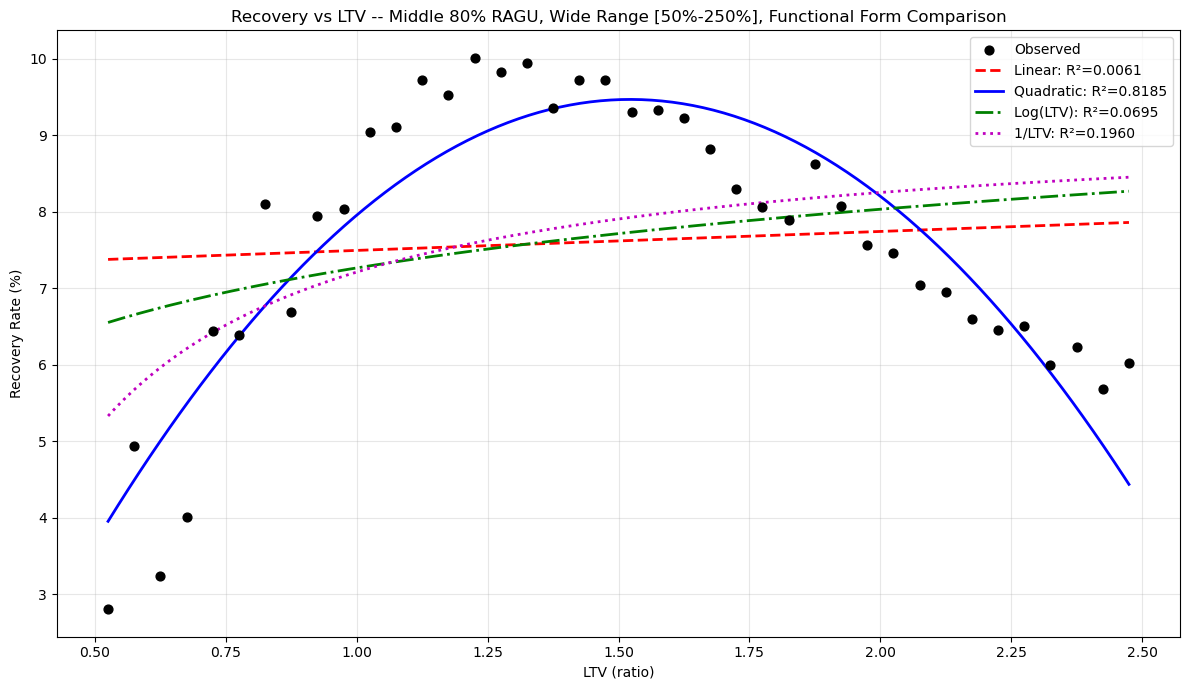


Functional form comparison (middle 80% RAGU, LTV 50%-250%, N bands=40):
  Model           R-squared    Formula
  -------------------------------------------------------
  Linear          0.0061       recovery = +0.07249 + +0.00248 * LTV
  Quadratic       0.8185       recovery = -0.05545*LTV² + +0.16884*LTV + -0.03381
  Log(LTV)        0.0695       recovery = +0.07268 + +0.01107 * ln(LTV)
  1/LTV           0.1960       recovery = +0.09295 + -0.02080 * (1/LTV)

  Population in [50%, 250%]: 278,400 / 359,860 (77.4%)


In [26]:
# Wide LTV range: 50% to 250% in 5% bands, middle 80% of RAGU
LTV_WIDE_MIN, LTV_WIDE_MAX, LTV_WIDE_STEP = 0.50, 2.50, 0.05
wide_bins = np.arange(LTV_WIDE_MIN, LTV_WIDE_MAX + LTV_WIDE_STEP, LTV_WIDE_STEP)
wide_labels = [f"{b:.0%}-{b + LTV_WIDE_STEP:.0%}" for b in wide_bins[:-1]]
mid80['ltv_band_wide'] = pd.cut(mid80['ltv'], bins=wide_bins, labels=wide_labels, right=False)

wide_grouped = mid80[mid80['ltv_band_wide'].notna()].groupby('ltv_band_wide', observed=True).agg(
    total_gross_loss=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proceeds=('proceeds', 'sum'),
    loan_count=('account_number', 'count')
).reset_index()
wide_grouped['recovery_rate'] = (wide_grouped['total_gross_loss'] - wide_grouped['total_cnl']) / wide_grouped['total_proceeds']

wide_midpoints = np.array([LTV_WIDE_MIN + i * LTV_WIDE_STEP + LTV_WIDE_STEP / 2 for i in range(len(wide_labels))])
# Only keep bands with enough observations
keep = wide_grouped['loan_count'] >= 100
x_w = wide_midpoints[keep.values]
y_w = wide_grouped.loc[keep, 'recovery_rate'].values

# Linear fit
slope_lin, intercept_lin, r_lin, _, _ = linregress(x_w, y_w)

# Quadratic fit
coeffs = np.polyfit(x_w, y_w, 2)
poly_fn = np.poly1d(coeffs)
ss_res = np.sum((y_w - poly_fn(x_w))**2)
ss_tot = np.sum((y_w - y_w.mean())**2)
r2_quad = 1 - ss_res / ss_tot

# Log fit: recovery = a + b * ln(LTV)
log_x = np.log(x_w)
slope_log, intercept_log, r_log, _, _ = linregress(log_x, y_w)

# 1/LTV fit: recovery = a + b * (1/LTV)
inv_x = 1.0 / x_w
slope_inv, intercept_inv, r_inv, _, _ = linregress(inv_x, y_w)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(x_w, y_w * 100, s=40, zorder=3, color='black', label='Observed')

x_smooth = np.linspace(x_w.min(), x_w.max(), 200)
ax.plot(x_smooth, (intercept_lin + slope_lin * x_smooth) * 100, 'r--', linewidth=2,
        label=f'Linear: R²={r_lin**2:.4f}')
ax.plot(x_smooth, poly_fn(x_smooth) * 100, 'b-', linewidth=2,
        label=f'Quadratic: R²={r2_quad:.4f}')
ax.plot(x_smooth, (intercept_log + slope_log * np.log(x_smooth)) * 100, 'g-.', linewidth=2,
        label=f'Log(LTV): R²={r_log**2:.4f}')
ax.plot(x_smooth, (intercept_inv + slope_inv / x_smooth) * 100, 'm:', linewidth=2,
        label=f'1/LTV: R²={r_inv**2:.4f}')

ax.set_xlabel('LTV (ratio)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Recovery vs LTV -- Middle 80% RAGU, Wide Range [50%-250%], Functional Form Comparison')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('recovery_vs_ltv_functional_form.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFunctional form comparison (middle 80% RAGU, LTV 50%-250%, N bands={keep.sum()}):")
print(f"  {'Model':<15} {'R-squared':<12} {'Formula'}")
print(f"  {'-'*55}")
print(f"  {'Linear':<15} {r_lin**2:<12.4f} recovery = {intercept_lin:+.5f} + {slope_lin:+.5f} * LTV")
print(f"  {'Quadratic':<15} {r2_quad:<12.4f} recovery = {coeffs[0]:+.5f}*LTV² + {coeffs[1]:+.5f}*LTV + {coeffs[2]:+.5f}")
print(f"  {'Log(LTV)':<15} {r_log**2:<12.4f} recovery = {intercept_log:+.5f} + {slope_log:+.5f} * ln(LTV)")
print(f"  {'1/LTV':<15} {r_inv**2:<12.4f} recovery = {intercept_inv:+.5f} + {slope_inv:+.5f} * (1/LTV)")
print(f"\n  Population in [50%, 250%]: {mid80['ltv_band_wide'].notna().sum():,} / {len(mid80):,} "
      f"({mid80['ltv_band_wide'].notna().mean():.1%})")

In [27]:
# Test all four functional forms across progressively narrower LTV ranges
# centered around the population median (~1.50)

LTV_RANGES = [
    (0.50, 2.50),  # Full wide range
    (0.60, 2.40),
    (0.70, 2.30),
    (0.80, 2.20),
    (0.90, 2.10),
    (1.00, 2.00),
    (1.00, 1.80),
    (1.10, 1.90),
    (1.10, 1.70),
    (1.20, 1.80),
]

STEP = 0.05
MIN_OBS_PER_BAND = 100

results = []
for ltv_lo, ltv_hi in LTV_RANGES:
    bins = np.arange(ltv_lo, ltv_hi + STEP, STEP)
    labels = [f"{b:.0%}-{b+STEP:.0%}" for b in bins[:-1]]
    mid80['_band'] = pd.cut(mid80['ltv'], bins=bins, labels=labels, right=False)

    grp = mid80[mid80['_band'].notna()].groupby('_band', observed=True).agg(
        total_gl=('gross_loss_amt', 'sum'),
        total_cnl=('net_loss_amt', 'sum'),
        total_proc=('proceeds', 'sum'),
        n=('account_number', 'count')
    )
    grp['rec'] = (grp['total_gl'] - grp['total_cnl']) / grp['total_proc']

    midpts = np.array([ltv_lo + i * STEP + STEP / 2 for i in range(len(labels))])
    keep = grp['n'].values >= MIN_OBS_PER_BAND
    if keep.sum() < 4:
        continue

    x = midpts[keep]
    y = grp['rec'].values[keep]
    n_bands = len(x)
    total_loans = grp.loc[keep, 'n'].sum()

    # Linear
    sl, il, rl, _, _ = linregress(x, y)
    r2_lin = rl**2

    # Quadratic
    c2 = np.polyfit(x, y, 2)
    yhat_q = np.polyval(c2, x)
    ss_res_q = np.sum((y - yhat_q)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_quad = 1 - ss_res_q / ss_tot if ss_tot > 0 else 0

    # 1/LTV
    sl_i, il_i, rl_i, _, _ = linregress(1.0 / x, y)
    r2_inv = rl_i**2

    # Log(LTV)
    sl_l, il_l, rl_l, _, _ = linregress(np.log(x), y)
    r2_log = rl_l**2

    results.append({
        'LTV Range': f"{ltv_lo:.0%}-{ltv_hi:.0%}",
        'N bands': n_bands,
        'Loans': total_loans,
        'Linear R²': r2_lin,
        'Quadratic R²': r2_quad,
        '1/LTV R²': r2_inv,
        'Log(LTV) R²': r2_log,
        'Best': max([('Linear', r2_lin), ('Quadratic', r2_quad), ('1/LTV', r2_inv), ('Log', r2_log)], key=lambda t: t[1])[0],
    })

mid80.drop(columns='_band', inplace=True)

results_df = pd.DataFrame(results)
print("=" * 95)
print("R-SQUARED BY FUNCTIONAL FORM ACROSS LTV RANGES (middle 80% RAGU, 5% bands, min 100 loans/band)")
print("=" * 95)
display(results_df.style.format({
    'Loans': '{:,.0f}',
    'Linear R²': '{:.4f}',
    'Quadratic R²': '{:.4f}',
    '1/LTV R²': '{:.4f}',
    'Log(LTV) R²': '{:.4f}',
}).highlight_max(subset=['Linear R²', 'Quadratic R²', '1/LTV R²', 'Log(LTV) R²'], axis=1, color='#90EE90'))

print(f"\nConclusion: Quadratic dominates across all ranges because the relationship")
print(f"is non-monotonic (recovery peaks mid-range then declines at both extremes).")
print(f"1/LTV assumes monotonically higher recovery at lower LTV, which breaks down")
print(f"in the tails where the population composition changes.")

R-SQUARED BY FUNCTIONAL FORM ACROSS LTV RANGES (middle 80% RAGU, 5% bands, min 100 loans/band)


,LTV Range,N bands,Loans,Linear R²,Quadratic R²,1/LTV R²,Log(LTV) R²,Best
0,50%-250%,40,"278,400",0.0061,0.8185,0.1960,0.0695,Quadratic
1,60%-240%,36,"272,957",0.0003,0.8051,0.1003,0.0218,Quadratic
2,70%-230%,32,"266,250",0.0735,0.8327,0.0001,0.0178,Quadratic
3,80%-220%,28,"257,703",0.1763,0.8155,0.0379,0.0967,Quadratic
4,90%-210%,24,"245,831",0.3173,0.8294,0.1492,0.2298,Quadratic
5,100%-200%,20,"228,207",0.5910,0.8321,0.4413,0.5189,Quadratic
6,100%-180%,16,"204,413",0.3203,0.8979,0.1992,0.2576,Quadratic
7,110%-190%,16,"200,440",0.7370,0.8200,0.6517,0.6978,Quadratic
8,110%-170%,12,"171,786",0.5439,0.7404,0.4682,0.5069,Quadratic
9,120%-180%,13,"166,838",0.8639,0.9414,0.7999,0.8338,Quadratic



Conclusion: Quadratic dominates across all ranges because the relationship
is non-monotonic (recovery peaks mid-range then declines at both extremes).
1/LTV assumes monotonically higher recovery at lower LTV, which breaks down
in the tails where the population composition changes.


R-SQUARED: NEGATIVE-SLOPE HALF ONLY (LTV >= 125%, middle 80% RAGU)
Only the downward-sloping portion of the recovery curve, right of the peak


,LTV Range,N bands,Loans,Linear R²,1/LTV R²,Log(LTV) R²,Quadratic R²,Best
0,125%-250%,25,"201,923",0.9629,0.9145,0.9467,0.9646,Quadratic
1,125%-225%,20,"187,497",0.9394,0.8840,0.9169,0.9533,Quadratic
2,125%-200%,15,"166,832",0.8629,0.8291,0.8494,0.8702,Quadratic
3,125%-180%,12,"149,850",0.8555,0.7953,0.8270,0.9408,Quadratic
4,130%-250%,24,"183,916",0.9631,0.9266,0.9520,0.9635,Quadratic
5,130%-200%,14,"148,825",0.8568,0.8353,0.8490,0.8588,Quadratic
6,135%-250%,23,"165,855",0.9591,0.9271,0.9496,0.9593,Quadratic
7,135%-200%,13,"130,764",0.8278,0.8061,0.8196,0.8309,Quadratic


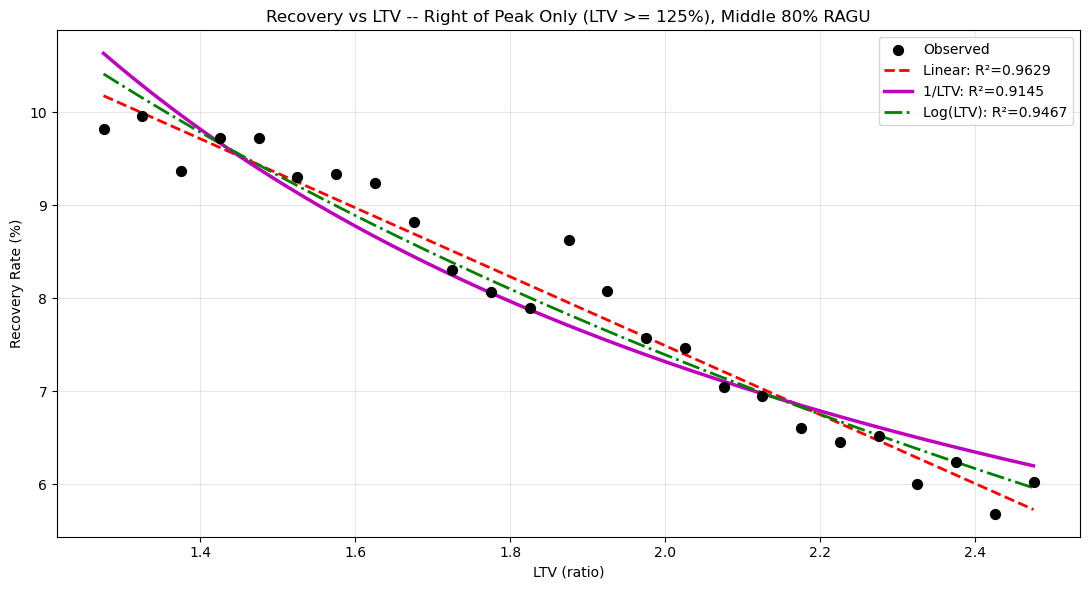

In [28]:
# Regress only the negative-slope half: LTV >= 125% (right of the peak)
LTV_PEAK = 1.25
RANGES_RIGHT = [
    (1.25, 2.50),
    (1.25, 2.25),
    (1.25, 2.00),
    (1.25, 1.80),
    (1.30, 2.50),
    (1.30, 2.00),
    (1.35, 2.50),
    (1.35, 2.00),
]

results_right = []
for ltv_lo, ltv_hi in RANGES_RIGHT:
    bins = np.arange(ltv_lo, ltv_hi + STEP, STEP)
    labels = [f"{b:.0%}-{b+STEP:.0%}" for b in bins[:-1]]
    mid80['_band'] = pd.cut(mid80['ltv'], bins=bins, labels=labels, right=False)

    grp = mid80[mid80['_band'].notna()].groupby('_band', observed=True).agg(
        total_gl=('gross_loss_amt', 'sum'),
        total_cnl=('net_loss_amt', 'sum'),
        total_proc=('proceeds', 'sum'),
        n=('account_number', 'count')
    )
    grp['rec'] = (grp['total_gl'] - grp['total_cnl']) / grp['total_proc']

    midpts = np.array([ltv_lo + i * STEP + STEP / 2 for i in range(len(labels))])
    keep = grp['n'].values >= MIN_OBS_PER_BAND
    if keep.sum() < 4:
        continue

    x = midpts[keep]
    y = grp['rec'].values[keep]
    total_loans = grp.loc[keep, 'n'].sum()

    # Linear (negative slope expected)
    sl, il, rl, _, _ = linregress(x, y)
    r2_lin = rl**2

    # 1/LTV
    sl_i, il_i, rl_i, _, _ = linregress(1.0 / x, y)
    r2_inv = rl_i**2

    # Log(LTV)
    sl_l, il_l, rl_l, _, _ = linregress(np.log(x), y)
    r2_log = rl_l**2

    # Quadratic (for comparison)
    c2 = np.polyfit(x, y, 2)
    yhat_q = np.polyval(c2, x)
    ss_res_q = np.sum((y - yhat_q)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_quad = 1 - ss_res_q / ss_tot if ss_tot > 0 else 0

    results_right.append({
        'LTV Range': f"{ltv_lo:.0%}-{ltv_hi:.0%}",
        'N bands': len(x),
        'Loans': total_loans,
        'Linear R²': r2_lin,
        '1/LTV R²': r2_inv,
        'Log(LTV) R²': r2_log,
        'Quadratic R²': r2_quad,
        'Best': max([('Linear', r2_lin), ('1/LTV', r2_inv), ('Log', r2_log), ('Quadratic', r2_quad)], key=lambda t: t[1])[0],
    })

mid80.drop(columns='_band', inplace=True)

results_right_df = pd.DataFrame(results_right)
print("=" * 95)
print(f"R-SQUARED: NEGATIVE-SLOPE HALF ONLY (LTV >= {LTV_PEAK:.0%}, middle 80% RAGU)")
print("Only the downward-sloping portion of the recovery curve, right of the peak")
print("=" * 95)
display(results_right_df.style.format({
    'Loans': '{:,.0f}',
    'Linear R²': '{:.4f}',
    '1/LTV R²': '{:.4f}',
    'Log(LTV) R²': '{:.4f}',
    'Quadratic R²': '{:.4f}',
}).highlight_max(subset=['Linear R²', '1/LTV R²', 'Log(LTV) R²', 'Quadratic R²'], axis=1, color='#90EE90'))

# Plot the best range with all fits overlaid
best_range = (1.25, 2.50)
bins_plot = np.arange(best_range[0], best_range[1] + STEP, STEP)
labels_plot = [f"{b:.0%}-{b+STEP:.0%}" for b in bins_plot[:-1]]
mid80['_band'] = pd.cut(mid80['ltv'], bins=bins_plot, labels=labels_plot, right=False)
grp_plot = mid80[mid80['_band'].notna()].groupby('_band', observed=True).agg(
    total_gl=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proc=('proceeds', 'sum'),
    n=('account_number', 'count')
)
grp_plot['rec'] = (grp_plot['total_gl'] - grp_plot['total_cnl']) / grp_plot['total_proc']
midpts_plot = np.array([best_range[0] + i * STEP + STEP / 2 for i in range(len(labels_plot))])
keep_plot = grp_plot['n'].values >= MIN_OBS_PER_BAND
x_p = midpts_plot[keep_plot]
y_p = grp_plot['rec'].values[keep_plot]
mid80.drop(columns='_band', inplace=True)

sl_p, il_p, rl_p, _, _ = linregress(x_p, y_p)
sl_ip, il_ip, rl_ip, _, _ = linregress(1.0 / x_p, y_p)
sl_lp, il_lp, rl_lp, _, _ = linregress(np.log(x_p), y_p)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(x_p, y_p * 100, s=50, color='black', zorder=3, label='Observed')
x_sm = np.linspace(x_p.min(), x_p.max(), 200)
ax.plot(x_sm, (il_p + sl_p * x_sm) * 100, 'r--', lw=2, label=f'Linear: R²={rl_p**2:.4f}')
ax.plot(x_sm, (il_ip + sl_ip / x_sm) * 100, 'm-', lw=2.5, label=f'1/LTV: R²={rl_ip**2:.4f}')
ax.plot(x_sm, (il_lp + sl_lp * np.log(x_sm)) * 100, 'g-.', lw=2, label=f'Log(LTV): R²={rl_lp**2:.4f}')

ax.set_xlabel('LTV (ratio)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Recovery vs LTV -- Right of Peak Only (LTV >= {LTV_PEAK:.0%}), Middle 80% RAGU')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('recovery_vs_ltv_right_of_peak.png', dpi=150, bbox_inches='tight')
plt.show()

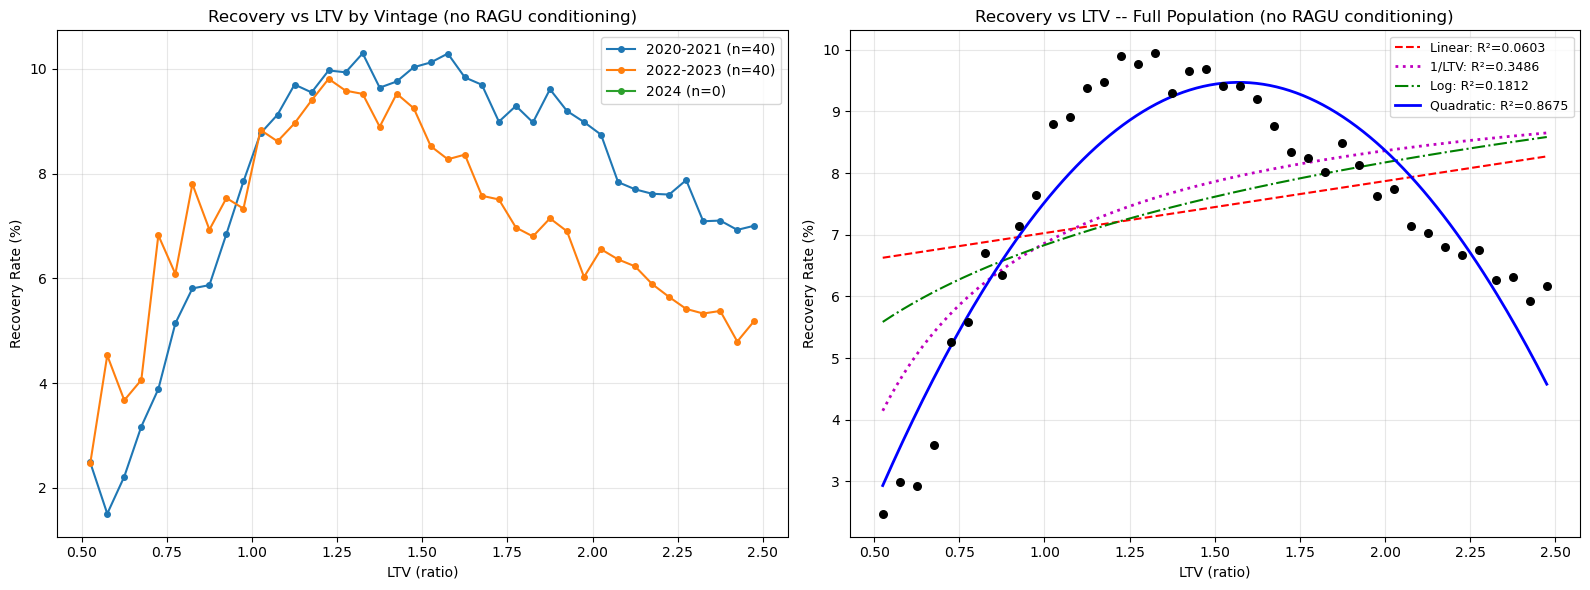


Functional form comparison -- FULL POPULATION (no RAGU conditioning):
  Model           R-squared   
  ------------------------------
  Linear          0.0603      
  1/LTV           0.3486      
  Log(LTV)        0.1812      
  Quadratic       0.8675      

  Quadratic peak at LTV = 1.570
  Population in window: 40 bands, 344,623 loans


In [29]:
# Recovery vs LTV conditioned on VINTAGE (uncorrelated with LTV) instead of RAGU score
# This avoids the selection bias from conditioning on gross_loss_ragu

merged['vintage_year'] = merged['book_date'].dt.year

VINTAGE_GROUPS = {
    '2020-2021': [2020, 2021],
    '2022-2023': [2022, 2023],
    '2024': [2024],
}

LTV_WIDE_MIN, LTV_WIDE_MAX, LTV_WIDE_STEP = 0.50, 2.50, 0.05
wide_bins = np.arange(LTV_WIDE_MIN, LTV_WIDE_MAX + LTV_WIDE_STEP, LTV_WIDE_STEP)
wide_labels = [f"{b:.0%}-{b+LTV_WIDE_STEP:.0%}" for b in wide_bins[:-1]]
wide_midpoints = np.array([LTV_WIDE_MIN + i * LTV_WIDE_STEP + LTV_WIDE_STEP / 2 for i in range(len(wide_labels))])

merged['ltv_band_wide'] = pd.cut(merged['ltv'], bins=wide_bins, labels=wide_labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Recovery vs LTV by vintage group
for vname, years in VINTAGE_GROUPS.items():
    vdata = merged[(merged['vintage_year'].isin(years)) & (merged['ltv_band_wide'].notna())]
    grp = vdata.groupby('ltv_band_wide', observed=True).agg(
        total_gl=('gross_loss_amt', 'sum'),
        total_cnl=('net_loss_amt', 'sum'),
        total_proc=('proceeds', 'sum'),
        n=('account_number', 'count')
    )
    grp['rec'] = (grp['total_gl'] - grp['total_cnl']) / grp['total_proc']
    keep = grp['n'].values >= 100
    axes[0].plot(wide_midpoints[keep], grp['rec'].values[keep] * 100, 'o-', markersize=4, label=f'{vname} (n={keep.sum()})')

axes[0].set_xlabel('LTV (ratio)')
axes[0].set_ylabel('Recovery Rate (%)')
axes[0].set_title('Recovery vs LTV by Vintage (no RAGU conditioning)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: All vintages combined -- functional form fits
all_valid = merged[merged['ltv_band_wide'].notna()]
grp_all = all_valid.groupby('ltv_band_wide', observed=True).agg(
    total_gl=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proc=('proceeds', 'sum'),
    n=('account_number', 'count')
)
grp_all['rec'] = (grp_all['total_gl'] - grp_all['total_cnl']) / grp_all['total_proc']
keep_all = grp_all['n'].values >= 100
x_all = wide_midpoints[keep_all]
y_all = grp_all['rec'].values[keep_all]

# Fits
sl_lin, il_lin, rl_lin, _, _ = linregress(x_all, y_all)
sl_inv, il_inv, rl_inv, _, _ = linregress(1.0 / x_all, y_all)
sl_log, il_log, rl_log, _, _ = linregress(np.log(x_all), y_all)
c_quad = np.polyfit(x_all, y_all, 2)
yhat_quad = np.polyval(c_quad, x_all)
r2_quad_all = 1 - np.sum((y_all - yhat_quad)**2) / np.sum((y_all - y_all.mean())**2)

axes[1].scatter(x_all, y_all * 100, s=30, color='black', zorder=3)
x_sm = np.linspace(x_all.min(), x_all.max(), 200)
axes[1].plot(x_sm, (il_lin + sl_lin * x_sm) * 100, 'r--', lw=1.5, label=f'Linear: R²={rl_lin**2:.4f}')
axes[1].plot(x_sm, (il_inv + sl_inv / x_sm) * 100, 'm:', lw=2, label=f'1/LTV: R²={rl_inv**2:.4f}')
axes[1].plot(x_sm, (il_log + sl_log * np.log(x_sm)) * 100, 'g-.', lw=1.5, label=f'Log: R²={rl_log**2:.4f}')
axes[1].plot(x_sm, np.polyval(c_quad, x_sm) * 100, 'b-', lw=2, label=f'Quadratic: R²={r2_quad_all:.4f}')
axes[1].set_xlabel('LTV (ratio)')
axes[1].set_ylabel('Recovery Rate (%)')
axes[1].set_title('Recovery vs LTV -- Full Population (no RAGU conditioning)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recovery_vs_ltv_by_vintage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFunctional form comparison -- FULL POPULATION (no RAGU conditioning):")
print(f"  {'Model':<15} {'R-squared':<12}")
print(f"  {'-'*30}")
print(f"  {'Linear':<15} {rl_lin**2:<12.4f}")
print(f"  {'1/LTV':<15} {rl_inv**2:<12.4f}")
print(f"  {'Log(LTV)':<15} {rl_log**2:<12.4f}")
print(f"  {'Quadratic':<15} {r2_quad_all:<12.4f}")
print(f"\n  Quadratic peak at LTV = {-c_quad[1] / (2 * c_quad[0]):.3f}")
print(f"  Population in window: {keep_all.sum()} bands, {grp_all.loc[keep_all, 'n'].sum():,} loans")

Middle 78% of LTV: [1.093, 2.522]
Loans: 304,215 / 449,826 (67.6%)


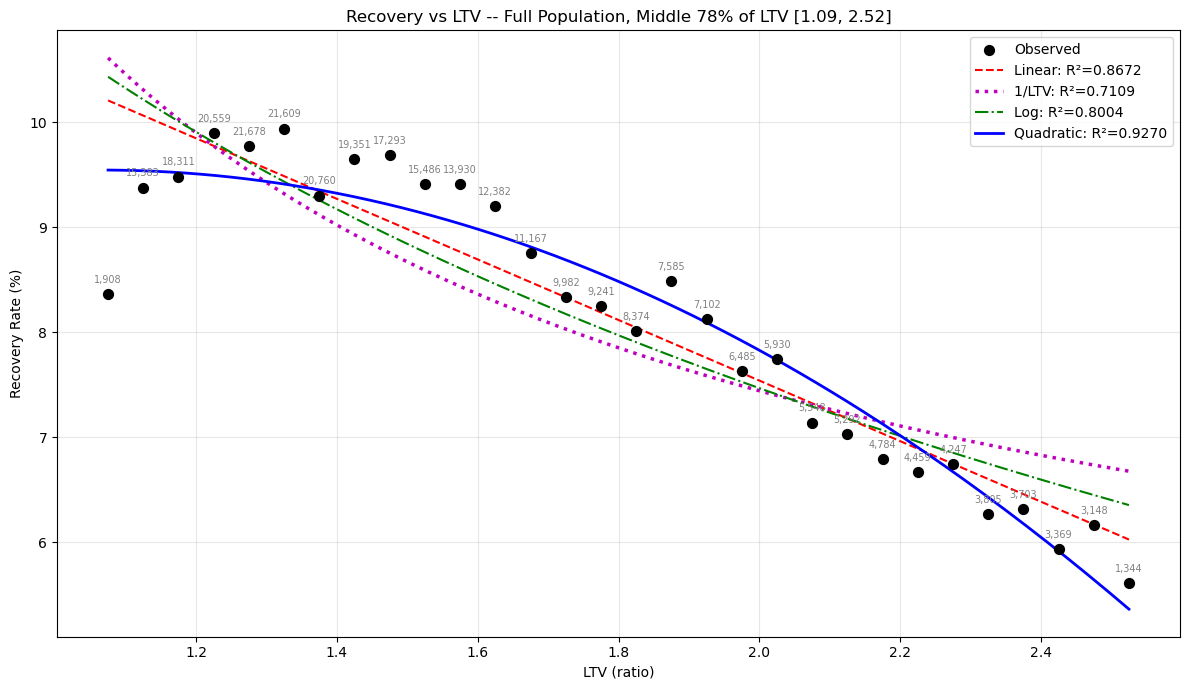


Functional form comparison -- Middle 78% of LTV, no RAGU conditioning:
  Model           R-squared    Formula
  -----------------------------------------------------------------
  Linear          0.8672       recovery = +0.13309 -0.02884 * LTV
  1/LTV           0.7109       recovery = +0.03758 +0.07370 * (1/LTV)
  Log(LTV)        0.8004       recovery = +0.10779 -0.04777 * ln(LTV)
  Quadratic       0.9270       recovery = -0.01960*LTV² +0.04171*LTV +0.07326

  Quadratic peak at LTV = 1.064
  N bands = 30, N loans = 304,215


In [31]:
# Final graph: full population, middle 78% of LTV (trim top/bottom 11%)
ltv_p11 = merged['ltv'].quantile(0.11)
ltv_p89 = merged['ltv'].quantile(0.89)
mid78_ltv = merged[(merged['ltv'] >= ltv_p11) & (merged['ltv'] <= ltv_p89)].copy()

print(f"Middle 78% of LTV: [{ltv_p11:.3f}, {ltv_p89:.3f}]")
print(f"Loans: {len(mid78_ltv):,} / {len(merged):,} ({len(mid78_ltv)/len(merged):.1%})")

# Bin into 5% bands within the middle 78% range
ltv_lo = np.floor(ltv_p11 / 0.05) * 0.05
ltv_hi = np.ceil(ltv_p89 / 0.05) * 0.05
bins_mid = np.arange(ltv_lo, ltv_hi + 0.05, 0.05)
labels_mid = [f"{b:.0%}-{b+0.05:.0%}" for b in bins_mid[:-1]]
midpts_mid = np.array([b + 0.025 for b in bins_mid[:-1]])

mid78_ltv['ltv_band_mid'] = pd.cut(mid78_ltv['ltv'], bins=bins_mid, labels=labels_mid, right=False)

grp_mid = mid78_ltv[mid78_ltv['ltv_band_mid'].notna()].groupby('ltv_band_mid', observed=True).agg(
    total_gl=('gross_loss_amt', 'sum'),
    total_cnl=('net_loss_amt', 'sum'),
    total_proc=('proceeds', 'sum'),
    n=('account_number', 'count')
)
grp_mid['rec'] = (grp_mid['total_gl'] - grp_mid['total_cnl']) / grp_mid['total_proc']

keep_mid = grp_mid['n'].values >= 100
x_m = midpts_mid[keep_mid]
y_m = grp_mid['rec'].values[keep_mid]

# Fits
sl_lin_m, il_lin_m, rl_lin_m, _, _ = linregress(x_m, y_m)
sl_inv_m, il_inv_m, rl_inv_m, _, _ = linregress(1.0 / x_m, y_m)
sl_log_m, il_log_m, rl_log_m, _, _ = linregress(np.log(x_m), y_m)
c_quad_m = np.polyfit(x_m, y_m, 2)
yhat_quad_m = np.polyval(c_quad_m, x_m)
r2_quad_m = 1 - np.sum((y_m - yhat_quad_m)**2) / np.sum((y_m - y_m.mean())**2)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(x_m, y_m * 100, s=50, color='black', zorder=3, label='Observed')

x_sm = np.linspace(x_m.min(), x_m.max(), 200)
ax.plot(x_sm, (il_lin_m + sl_lin_m * x_sm) * 100, 'r--', lw=1.5, label=f'Linear: R²={rl_lin_m**2:.4f}')
ax.plot(x_sm, (il_inv_m + sl_inv_m / x_sm) * 100, 'm:', lw=2.5, label=f'1/LTV: R²={rl_inv_m**2:.4f}')
ax.plot(x_sm, (il_log_m + sl_log_m * np.log(x_sm)) * 100, 'g-.', lw=1.5, label=f'Log: R²={rl_log_m**2:.4f}')
ax.plot(x_sm, np.polyval(c_quad_m, x_sm) * 100, 'b-', lw=2, label=f'Quadratic: R²={r2_quad_m:.4f}')

for i in range(len(x_m)):
    ax.annotate(f"{grp_mid['n'].values[keep_mid][i]:,.0f}",
                (x_m[i], y_m[i] * 100), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=7, color='gray')

ax.set_xlabel('LTV (ratio)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title(f'Recovery vs LTV -- Full Population, Middle 78% of LTV [{ltv_p11:.2f}, {ltv_p89:.2f}]')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('recovery_vs_ltv_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFunctional form comparison -- Middle 78% of LTV, no RAGU conditioning:")
print(f"  {'Model':<15} {'R-squared':<12} {'Formula'}")
print(f"  {'-'*65}")
print(f"  {'Linear':<15} {rl_lin_m**2:<12.4f} recovery = {il_lin_m:+.5f} {sl_lin_m:+.5f} * LTV")
print(f"  {'1/LTV':<15} {rl_inv_m**2:<12.4f} recovery = {il_inv_m:+.5f} {sl_inv_m:+.5f} * (1/LTV)")
print(f"  {'Log(LTV)':<15} {rl_log_m**2:<12.4f} recovery = {il_log_m:+.5f} {sl_log_m:+.5f} * ln(LTV)")
print(f"  {'Quadratic':<15} {r2_quad_m:<12.4f} recovery = {c_quad_m[0]:+.5f}*LTV² {c_quad_m[1]:+.5f}*LTV {c_quad_m[2]:+.5f}")
print(f"\n  Quadratic peak at LTV = {-c_quad_m[1] / (2 * c_quad_m[0]):.3f}")
print(f"  N bands = {keep_mid.sum()}, N loans = {grp_mid.loc[keep_mid, 'n'].sum():,}")